# DWA Demo (Dynamic Window Approach)

This notebook is a self-learning walkthrough of DWA local planning.

You will sample feasible velocity commands, roll out short trajectories, score them, and apply the best one repeatedly.

In [14]:
%matplotlib inline

import math

import matplotlib.pyplot as plt
import numpy as np

## 1. Environment and robot state

In [15]:
H, W = 12.0, 12.0
obstacles = np.array([
    [4.0, 5.0], [4.4, 5.5], [4.8, 6.0],
    [7.0, 7.2], [7.5, 7.0], [8.0, 6.8],
    [6.2, 3.6], [6.6, 3.2]
])

start = np.array([1.0, 1.0, 0.0])  # x, y, yaw
goal = np.array([10.5, 10.0])

state = start.copy()
trajectory = [state.copy()]

## 2. DWA parameters and helper functions

Focus points:
- The dynamic window is limited by current speed and acceleration.
- Each sampled `(v, w)` command is rolled out over a short horizon.

Classical DWA additionally restricts the dynamic window to commands from which the robot can safely stop before collision. This simplified educational implementation only considers velocity and acceleration limits.

In [16]:
# Robot limits
v_min, v_max = 0.0, 1.0
w_min, w_max = -1.2, 1.2
a_v, a_w = 0.4, 1.0

# Sampling and horizon
dt = 0.1
predict_time = 1.2
v_samples = 7
w_samples = 9

# Scoring weights
w_goal = 1.2
w_speed = 0.25
w_clear = 1.4

robot_radius = 0.25

def step_motion(s, v, w, dt_local):
    x, y, yaw = s
    yaw2 = yaw + w * dt_local
    x2 = x + v * math.cos(yaw2) * dt_local
    y2 = y + v * math.sin(yaw2) * dt_local
    return np.array([x2, y2, yaw2])

def rollout(s, v, w):
    points = [s.copy()]
    cur = s.copy()
    n = int(predict_time / dt)
    for _ in range(n):
        cur = step_motion(cur, v, w, dt)
        points.append(cur.copy())
    return np.array(points)

def min_clearance(path_xy, obs):
    if len(obs) == 0:
        return 10.0
    dmin = float('inf')
    for p in path_xy:
        d = np.linalg.norm(obs - p[:2], axis=1).min()
        if d < dmin:
            dmin = d
    return dmin

## 3. One DWA decision step

In each step:
1. Build the admissible dynamic window around current `(v, w)`.
2. Simulate all sampled commands.
3. Reject colliding trajectories.
4. Score and pick the best command.

In [17]:
def dwa_select_command(s, v_curr, w_curr):
    # This simplified demo uses velocity and acceleration limits only.
    # Classical DWA also keeps only commands from which the robot can safely stop before collision.
    v_low = max(v_min, v_curr - a_v * dt)
    v_high = min(v_max, v_curr + a_v * dt)
    w_low = max(w_min, w_curr - a_w * dt)
    w_high = min(w_max, w_curr + a_w * dt)

    v_grid = np.linspace(v_low, v_high, v_samples)
    w_grid = np.linspace(w_low, w_high, w_samples)

    best = None
    best_traj = None

    for v in v_grid:
        for w in w_grid:
            traj = rollout(s, v, w)
            clearance = min_clearance(traj, obstacles)

            if clearance <= robot_radius:
                continue

            end_xy = traj[-1, :2]
            goal_term = -np.linalg.norm(goal - end_xy)
            speed_term = v
            clear_term = min(clearance, 2.0)

            score = w_goal * goal_term + w_speed * speed_term + w_clear * clear_term

            if best is None or score > best[0]:
                best = (score, v, w, clearance)
                best_traj = traj

    return best, best_traj

## 4. Run the local planning loop

We repeatedly choose a short-horizon command and move one control step.

Learning check:
- If the robot gets stuck, which weights might need adjustment?

In [18]:
v_curr, w_curr = 0.0, 0.0
controls = []
planned_local_trajs = []

max_steps = 140
goal_tol = 0.35

for _ in range(max_steps):
    dist_goal = np.linalg.norm(goal - state[:2])
    if dist_goal <= goal_tol:
        break

    best, best_traj = dwa_select_command(state, v_curr, w_curr)
    if best is None:
        print('No collision-free command found. Stopping.')
        break

    _, v_cmd, w_cmd, clearance = best
    controls.append((v_cmd, w_cmd, clearance))
    planned_local_trajs.append(best_traj)

    state = step_motion(state, v_cmd, w_cmd, dt)
    v_curr, w_curr = v_cmd, w_cmd
    trajectory.append(state.copy())

trajectory = np.array(trajectory)
print('Steps executed:', len(trajectory) - 1)
print('Goal reached:', np.linalg.norm(goal - trajectory[-1, :2]) <= goal_tol)

Steps executed: 140
Goal reached: False


## 5. Visualize and interpret

The blue path is the executed robot trajectory.
Dashed segments are sampled best local rollouts at selected times.

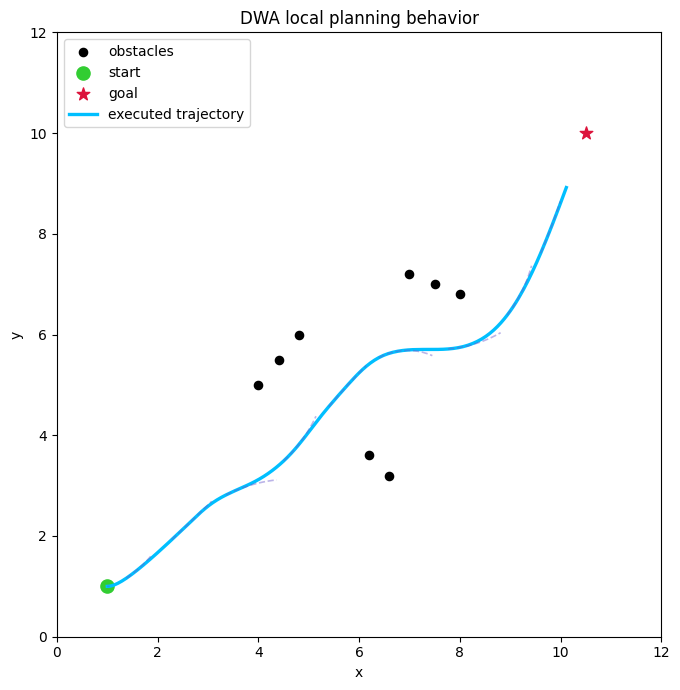

In [19]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_xlim(0, W)
ax.set_ylim(0, H)
ax.set_aspect('equal')

ax.scatter(obstacles[:, 0], obstacles[:, 1], c='black', s=35, label='obstacles')
ax.scatter(start[0], start[1], c='limegreen', s=90, marker='o', label='start')
ax.scatter(goal[0], goal[1], c='crimson', s=90, marker='*', label='goal')

ax.plot(trajectory[:, 0], trajectory[:, 1], color='deepskyblue', linewidth=2.4, label='executed trajectory')

if planned_local_trajs:
    stride = max(1, len(planned_local_trajs) // 10)
    for t in planned_local_trajs[::stride]:
        ax.plot(t[:, 0], t[:, 1], '--', color='slateblue', alpha=0.45, linewidth=1.2)

ax.set_title('DWA local planning behavior')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 6. Self-study experiments

Try these modifications and rerun:
1. Increase `w_clear` and see if the robot keeps more distance from obstacles.
2. Increase `w_speed` and observe speed-vs-safety tradeoff.
3. Increase `predict_time` and compare smoothness vs responsiveness.